In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

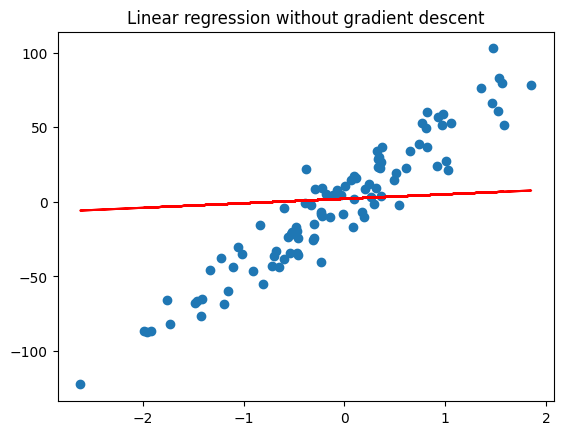

In [7]:
X,y=make_regression(n_samples=100,n_features=1,noise=15,random_state=42)
slope=3
intercept=2

y_pred=intercept+slope*X

plt.scatter(X,y)
plt.plot(X,y_pred,color='red')
plt.title("Linear regression without gradient descent")
plt.show()



Final Theta: [[ 1.16511457]
 [44.43716839]]


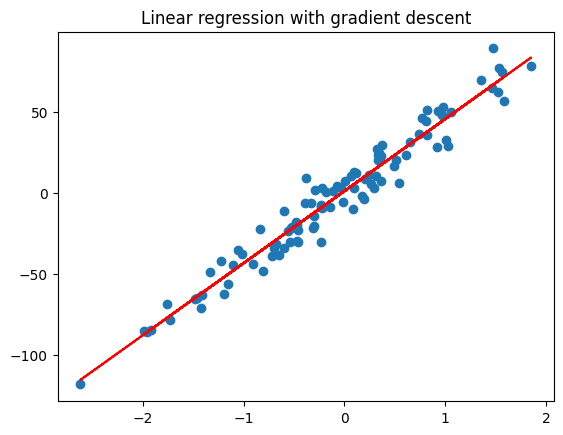

In [12]:
#Gradient Descent
X,y=make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
y=y.reshape(-1,1)

m=len(X)
X_b=np.c_[np.ones((m,1)),X]
theta=np.random.randn(2,1)

learning_rate=0.1
n_iterations=100

for i in range(n_iterations):
    prediction=X_b@theta
    error=prediction-y
    gradient=(2/m)* X_b.T@error
    theta=theta-learning_rate*gradient

print("Final Theta:",theta)

plt.scatter(X,y)
plt.plot(X,prediction,color='red')
plt.title("Linear regression with gradient descent")
plt.show()



Intercept:
 1.7476729807904583
Slope:
 [45.78520483]


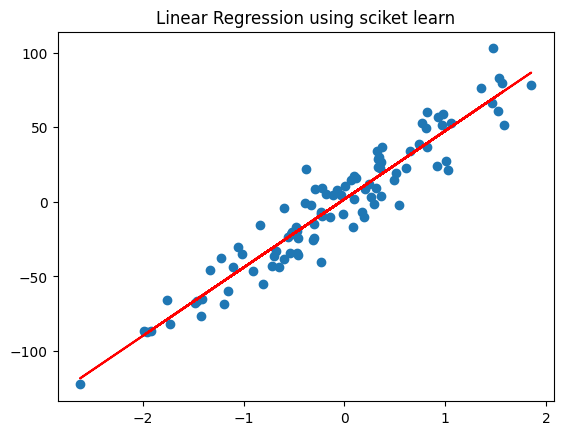

In [16]:
#Linear Regression using sciket learn
# from sklearn.model_selection import train_test_sample
from sklearn.linear_model import LinearRegression

X,y=make_regression(n_samples=100,n_features=1,noise=15,random_state=42)
model=LinearRegression()
model.fit(X,y)

y_pred=model.predict(X)

print("Intercept:\n",model.intercept_)
print("Slope:\n",model.coef_)

plt.scatter(X,y)
plt.plot(X,y_pred,color='red')
plt.title("Linear Regression using sciket learn")
plt.show()


In [22]:
#Applying lasso regularization and comparing with linear regression
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error,r2_score

X,y=make_regression(n_samples=100,n_features=10,n_informative=3,noise=15,random_state=42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

lr=LinearRegression()
lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)
print("Linear regression MSE:",mean_squared_error(y_test,lr_pred))
print("Linear regression Coefficient:")
print(np.round(lr.coef_,2))


print("------------------------")


lasso=Lasso(alpha=0.5)
lasso.fit(X_train,y_train)

lasso_pred=lasso.predict(X_test)

print("Linear Regression with Lasso regression:",mean_squared_error(y_test,lasso_pred))
print("Linear regression coefficient:")
print(np.round(lasso.coef_,2))
      

Linear regression MSE: 284.3893069678129
Linear regression Coefficient:
[17.02  0.49  1.09 62.25  2.97 -0.64 -1.45  8.97  0.48 -1.3 ]
------------------------
Linear Regression with Lasso regression: 294.628155318738
Linear regression coefficient:
[16.38  0.    0.23 61.51  2.33 -0.2  -0.8   8.51  0.   -0.46]


In [25]:
#Under Fitting and overfitting
X,y=make_regression(n_samples=100,n_features=1,n_infromaticnoise=15,random_state=42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

train_pred=model.predict(X_train)
test_pred=model.predict(X_test)


train_mse=mean_squared_error(y_train,train_pred)
test_mse=mean_squared_error(y_test,test_pred)

print("Trained mean Squared Error:",train_mse)
print("Test mean Squared Error:",test_mse)

Trained mean Squared Error: 164.07568773232416
Test mean Squared Error: 234.45500969670806
